In [ ]:
# 1) Kütüphaneler
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [ ]:
df = pd.read_csv("default_of_credit_card_clients.csv", header=1)

print("Veri boyutu:", df.shape)
df.head()

Veri boyutu: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
# 3) Temizleme
df = df.rename(columns={'default payment next month': 'default'})

if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

print(df.columns)
df.head()

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object')


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
# 4) Temel bilgi
display(df.info())
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

None

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [ ]:
# 5) Eksik veri kontrolü
missing = df.isnull().sum().sort_values(ascending=False)
display(missing)



,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


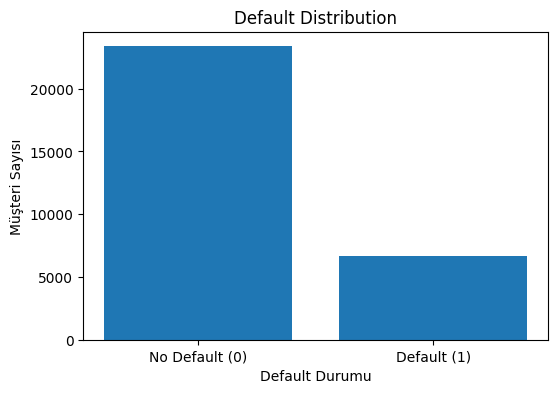

default
0    23364
1     6636
Name: count, dtype: int64
default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [ ]:
# 6) Default dağılımı - senin mevcut grafiğinin geliştirilmiş hali
counts = df['default'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Default (0)", "Default (1)"], counts.values)
plt.xlabel("Default Durumu")
plt.ylabel("Müşteri Sayısı")
plt.title("Default Distribution")
plt.show()

print(counts)
print(df['default'].value_counts(normalize=True))

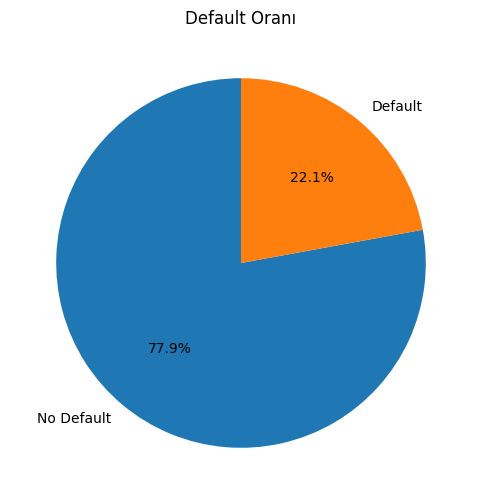

In [ ]:
# 7) Default dağılımı - pasta grafik
plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=["No Default", "Default"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Default Oranı")
plt.show()

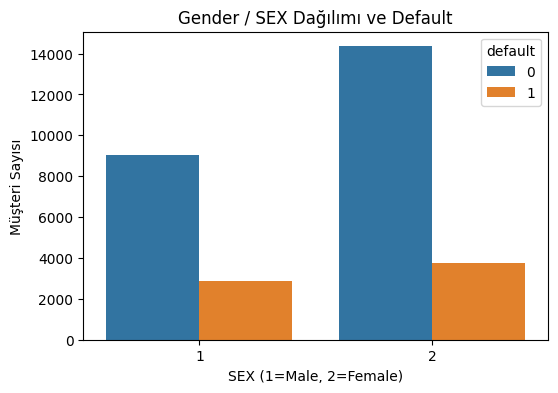

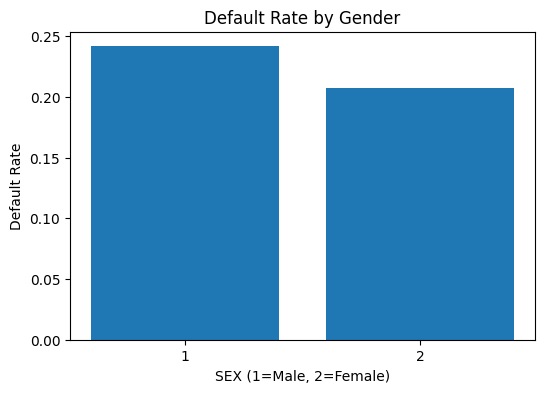

In [ ]:
# 8) Cinsiyet dağılımı ve default oranı
# Veri setinde genelde: SEX 1 = Male, 2 = Female
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="SEX", hue="default")
plt.title("Gender / SEX Dağılımı ve Default")
plt.xlabel("SEX (1=Male, 2=Female)")
plt.ylabel("Müşteri Sayısı")
plt.show()

gender_default = df.groupby("SEX")["default"].mean()

plt.figure(figsize=(6, 4))
plt.bar(gender_default.index.astype(str), gender_default.values)
plt.xlabel("SEX (1=Male, 2=Female)")
plt.ylabel("Default Rate")
plt.title("Default Rate by Gender")
plt.show()

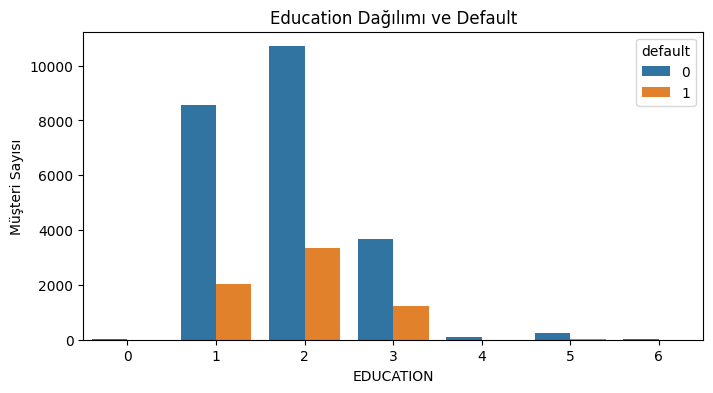

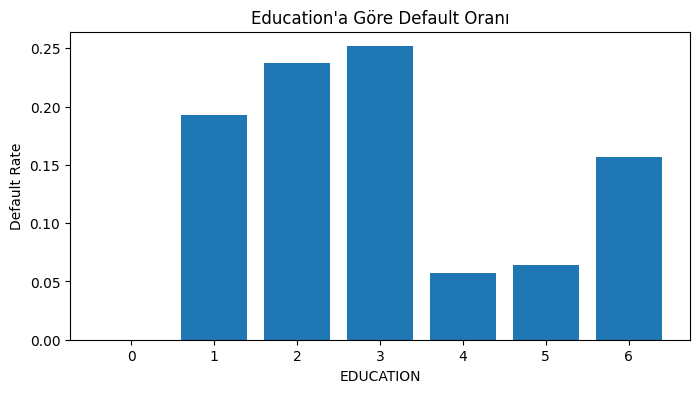

In [ ]:
# 9) Eğitim durumu grafikleri
# EDUCATION: 1=Graduate School, 2=University, 3=High School, 4+=Others gibi düşünülebilir.
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="EDUCATION", hue="default")
plt.title("Education Dağılımı ve Default")
plt.xlabel("EDUCATION")
plt.ylabel("Müşteri Sayısı")
plt.show()

education_default = df.groupby("EDUCATION")["default"].mean().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(education_default.index.astype(str), education_default.values)
plt.title("Education'a Göre Default Oranı")
plt.xlabel("EDUCATION")
plt.ylabel("Default Rate")
plt.show()

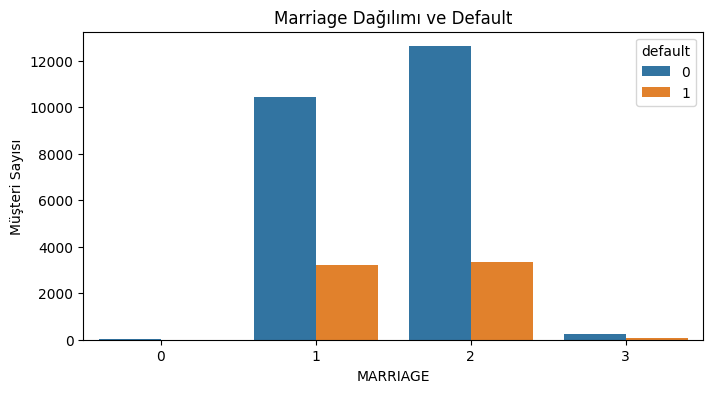

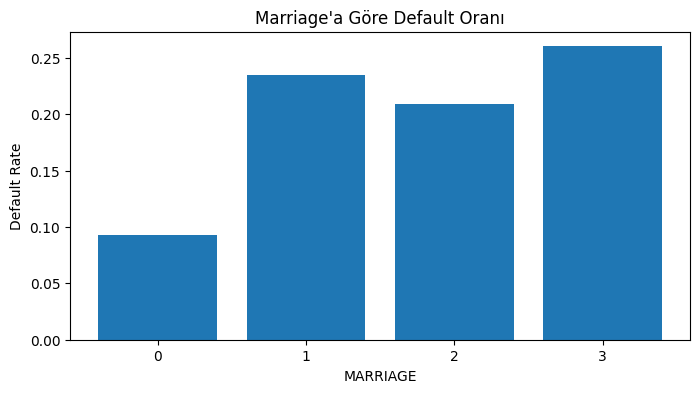

In [ ]:
# 10) Medeni durum grafikleri
# MARRIAGE: 1=Married, 2=Single, 3=Others gibi düşünülebilir.
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="MARRIAGE", hue="default")
plt.title("Marriage Dağılımı ve Default")
plt.xlabel("MARRIAGE")
plt.ylabel("Müşteri Sayısı")
plt.show()

marriage_default = df.groupby("MARRIAGE")["default"].mean().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(marriage_default.index.astype(str), marriage_default.values)
plt.title("Marriage'a Göre Default Oranı")
plt.xlabel("MARRIAGE")
plt.ylabel("Default Rate")
plt.show()

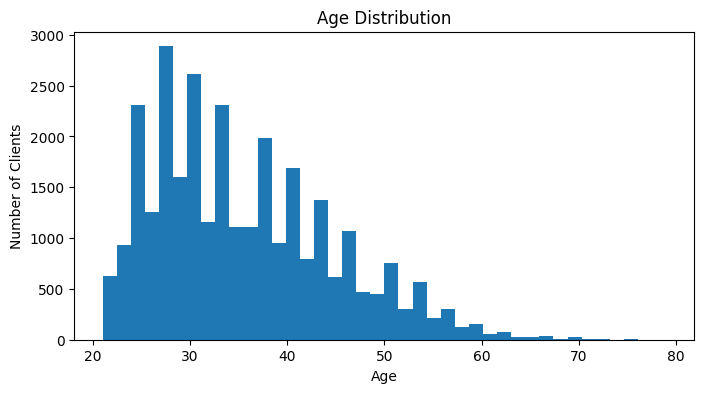

In [ ]:
# 11) Yaş dağılımı - senin mevcut grafiğin
plt.figure(figsize=(8, 4))
plt.hist(df["AGE"], bins=40)
plt.xlabel("Age")
plt.ylabel("Number of Clients")
plt.title("Age Distribution")
plt.show()

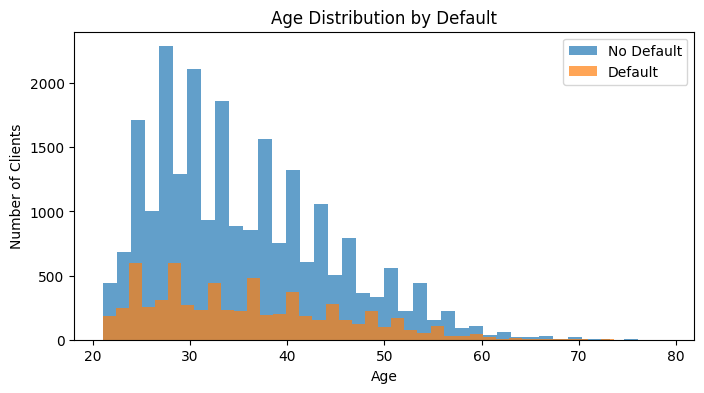

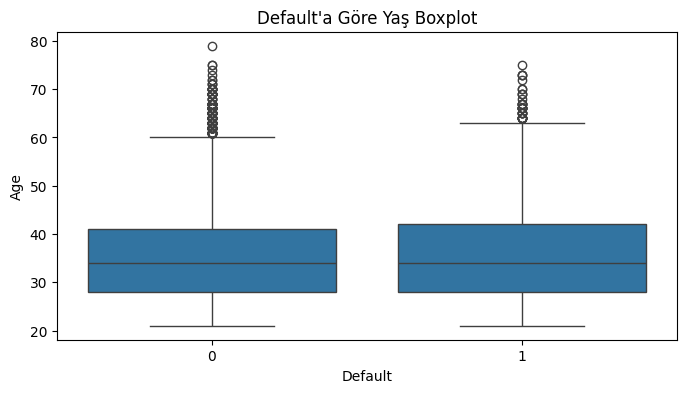

In [ ]:
# 12) Yaşa göre default karşılaştırması
plt.figure(figsize=(8, 4))
plt.hist(df[df["default"] == 0]["AGE"], bins=40, alpha=0.7, label="No Default")
plt.hist(df[df["default"] == 1]["AGE"], bins=40, alpha=0.7, label="Default")
plt.xlabel("Age")
plt.ylabel("Number of Clients")
plt.title("Age Distribution by Default")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="default", y="AGE")
plt.title("Default'a Göre Yaş Boxplot")
plt.xlabel("Default")
plt.ylabel("Age")
plt.show()

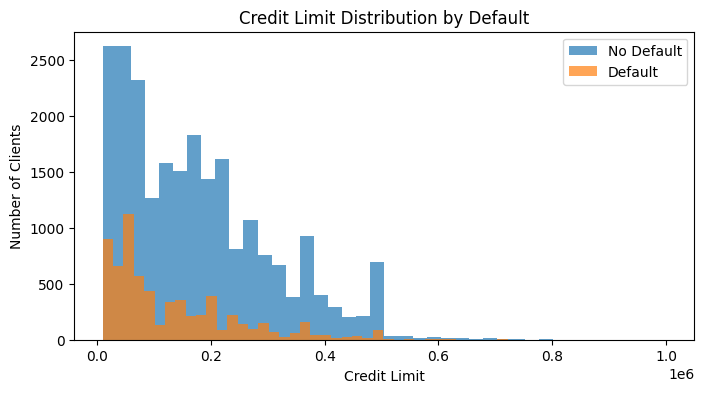

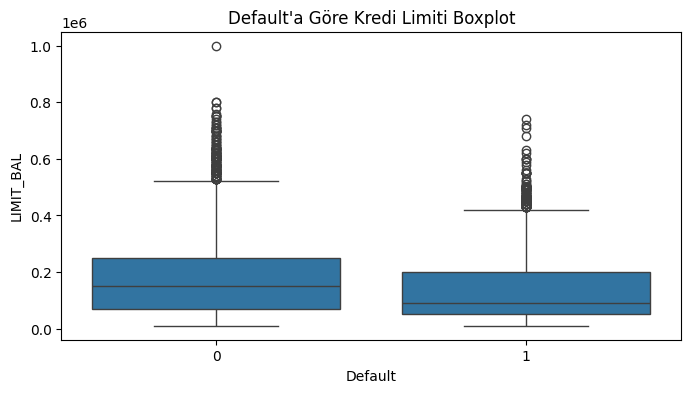

In [ ]:
# 13) Kredi limiti dağılımı - senin mevcut grafiğin
plt.figure(figsize=(8, 4))
plt.hist(df[df["default"] == 0]["LIMIT_BAL"], bins=40, alpha=0.7, label="No Default")
plt.hist(df[df["default"] == 1]["LIMIT_BAL"], bins=40, alpha=0.7, label="Default")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Clients")
plt.title("Credit Limit Distribution by Default")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="default", y="LIMIT_BAL")
plt.title("Default'a Göre Kredi Limiti Boxplot")
plt.xlabel("Default")
plt.ylabel("LIMIT_BAL")
plt.show()

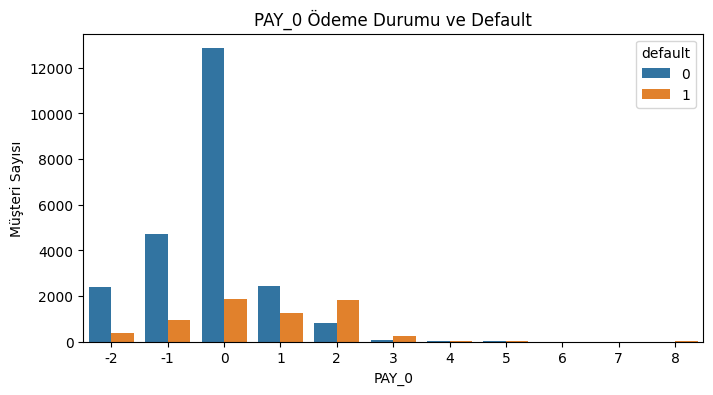

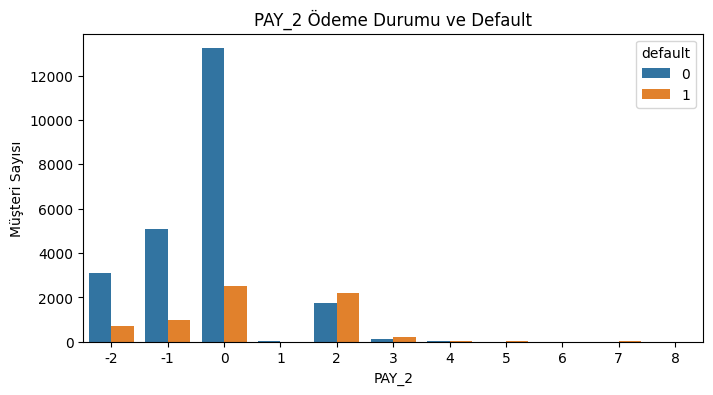

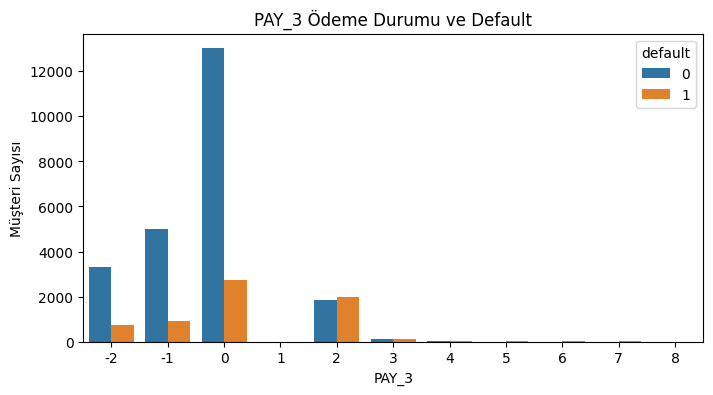

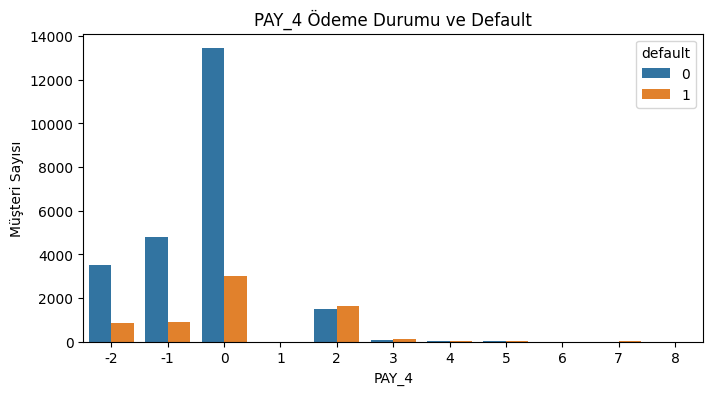

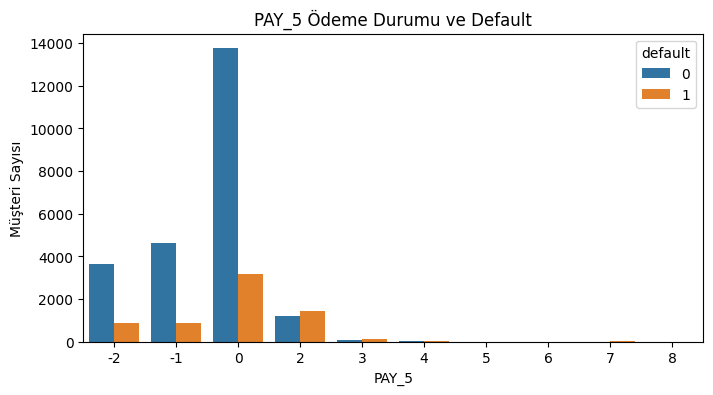

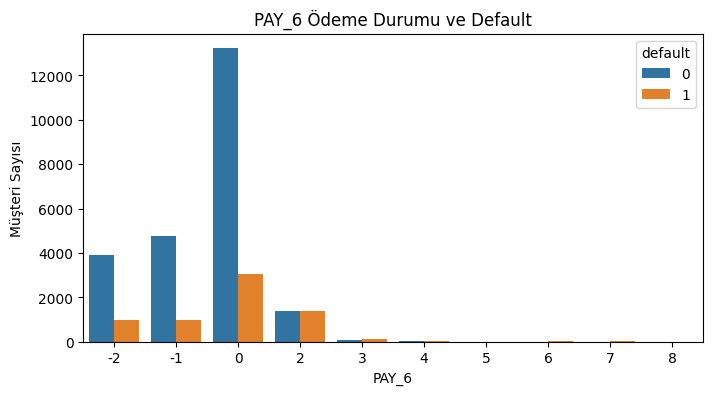

In [ ]:
# 14) PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6 grafikleri
pay_cols = [col for col in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] if col in df.columns]

for col in pay_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="default")
    plt.title(f"{col} Ödeme Durumu ve Default")
    plt.xlabel(col)
    plt.ylabel("Müşteri Sayısı")
    plt.show()

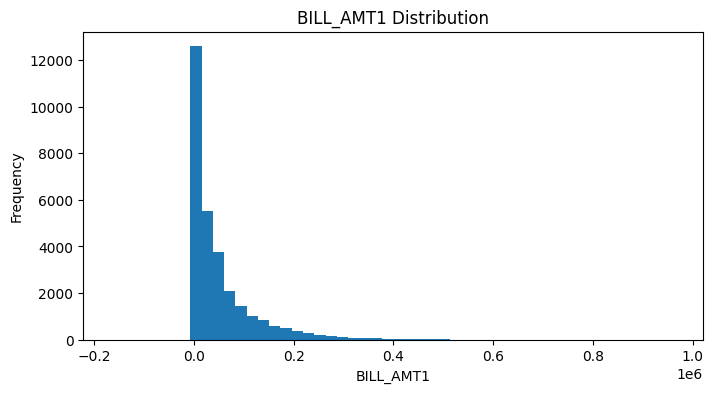

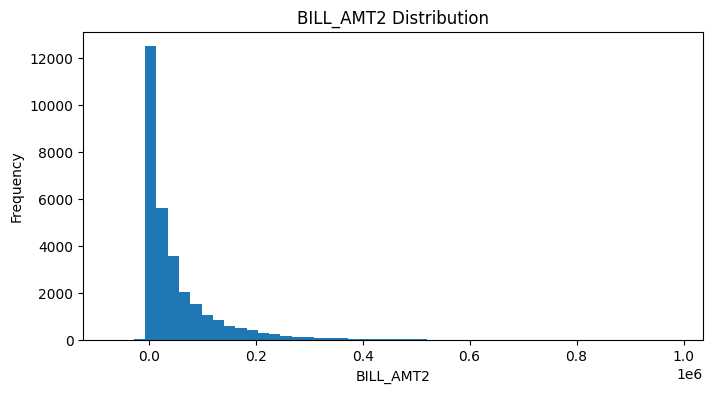

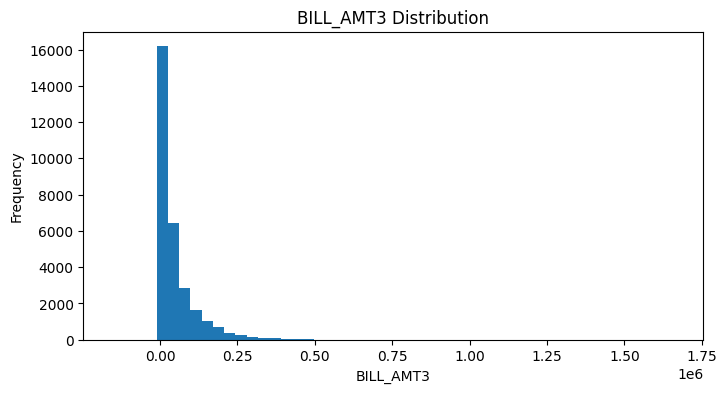

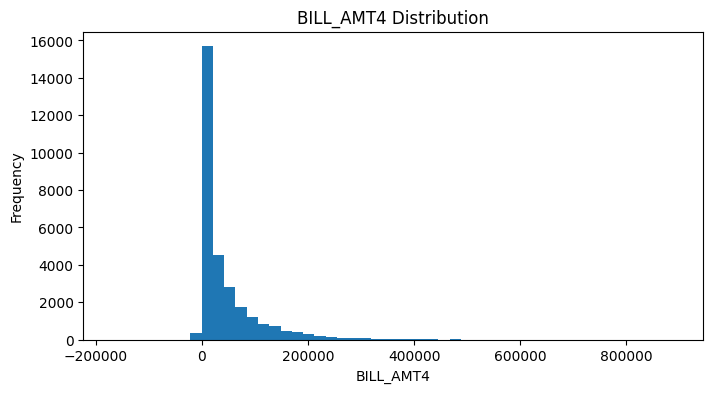

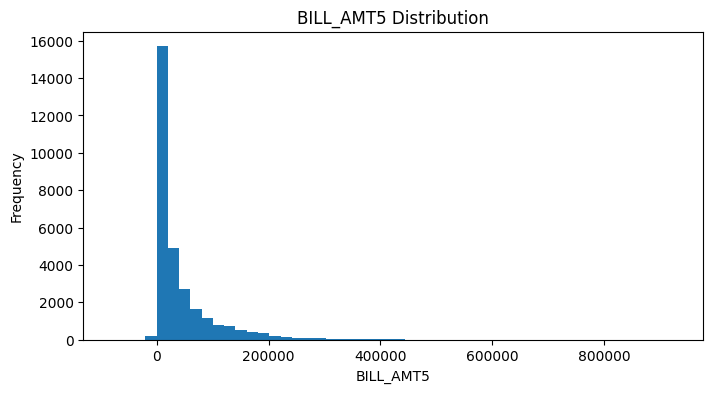

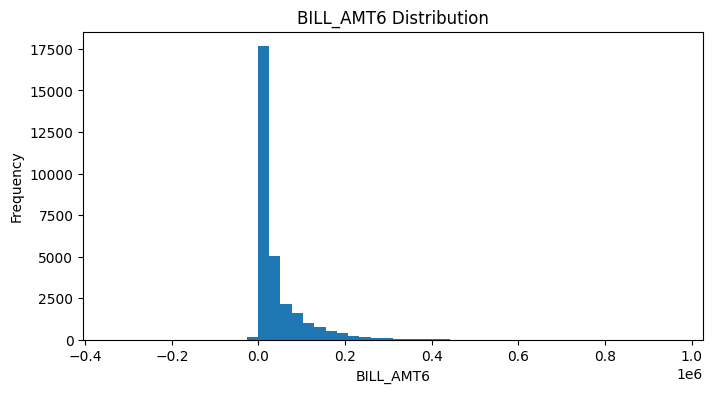

In [ ]:
# 15) BILL_AMT sütunlarının dağılımı
bill_cols = [col for col in df.columns if col.startswith("BILL_AMT")]

for col in bill_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=50)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

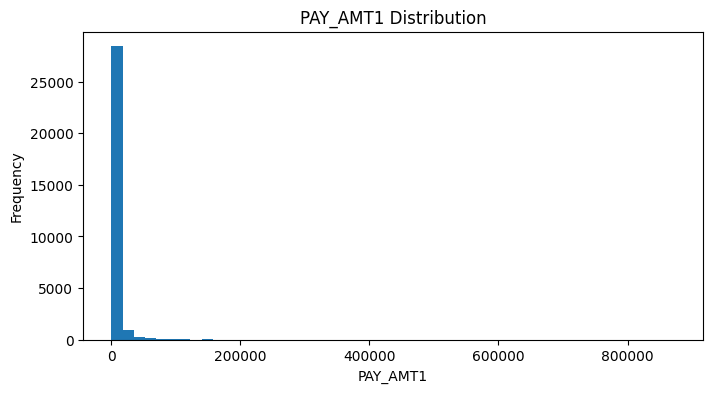

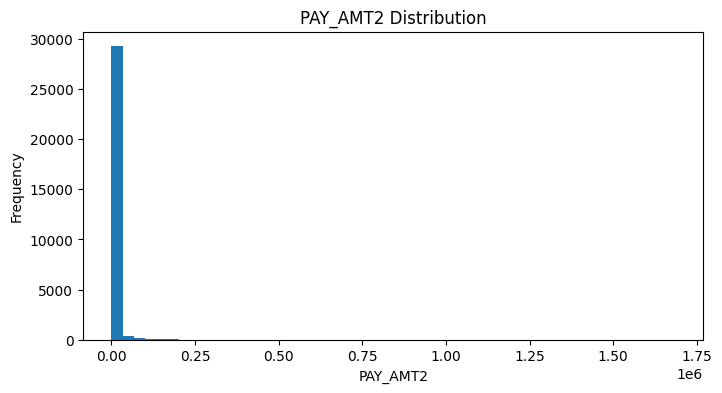

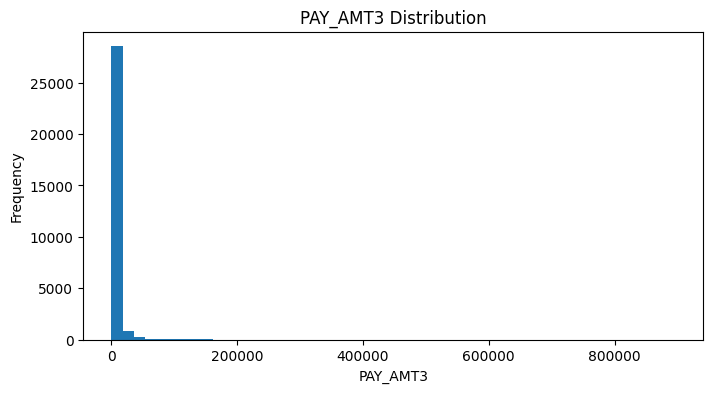

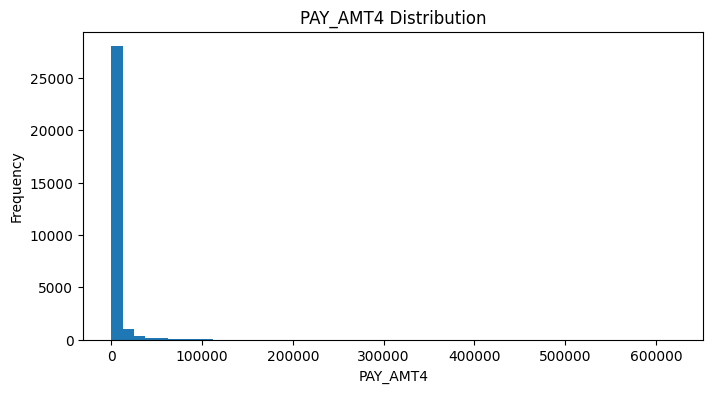

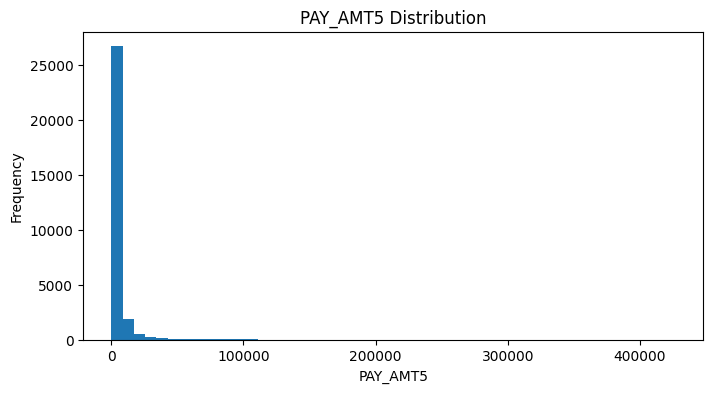

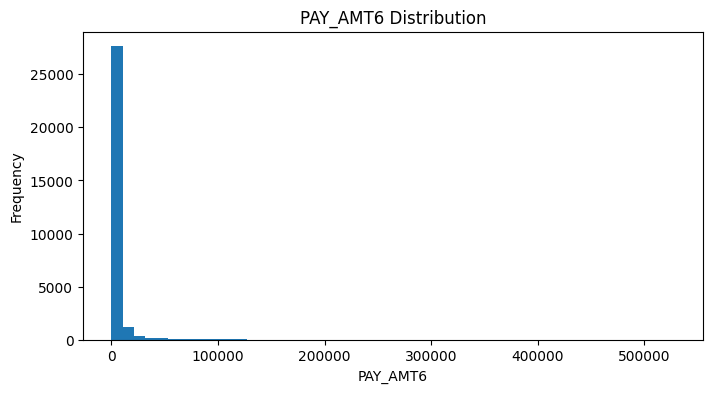

In [ ]:
# 16) PAY_AMT sütunlarının dağılımı
pay_amt_cols = [col for col in df.columns if col.startswith("PAY_AMT")]

for col in pay_amt_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=50)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

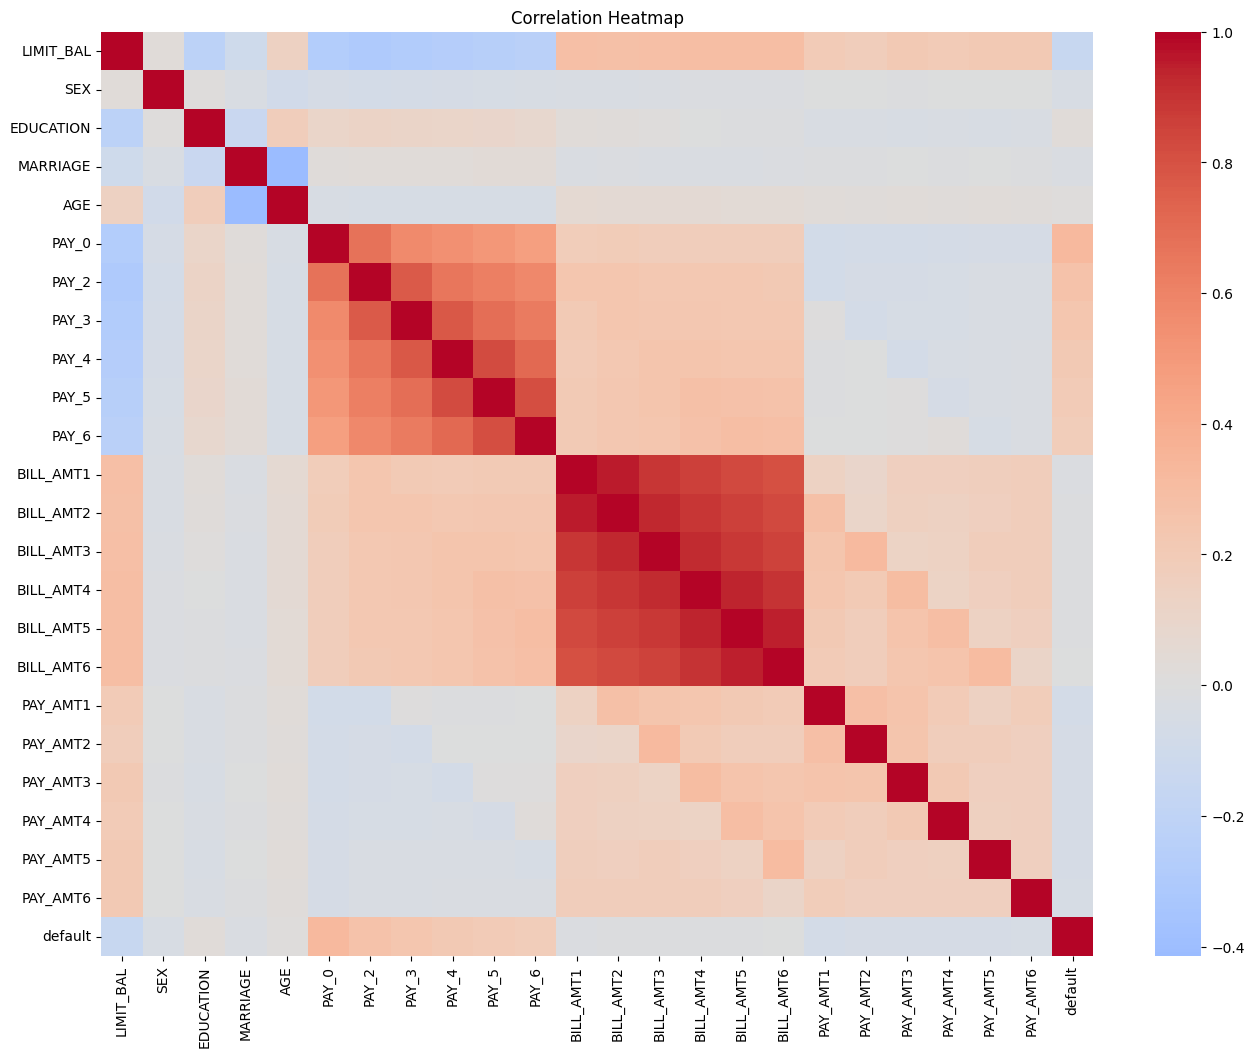

In [ ]:
# 17) Korelasyon heatmap
plt.figure(figsize=(16, 12))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

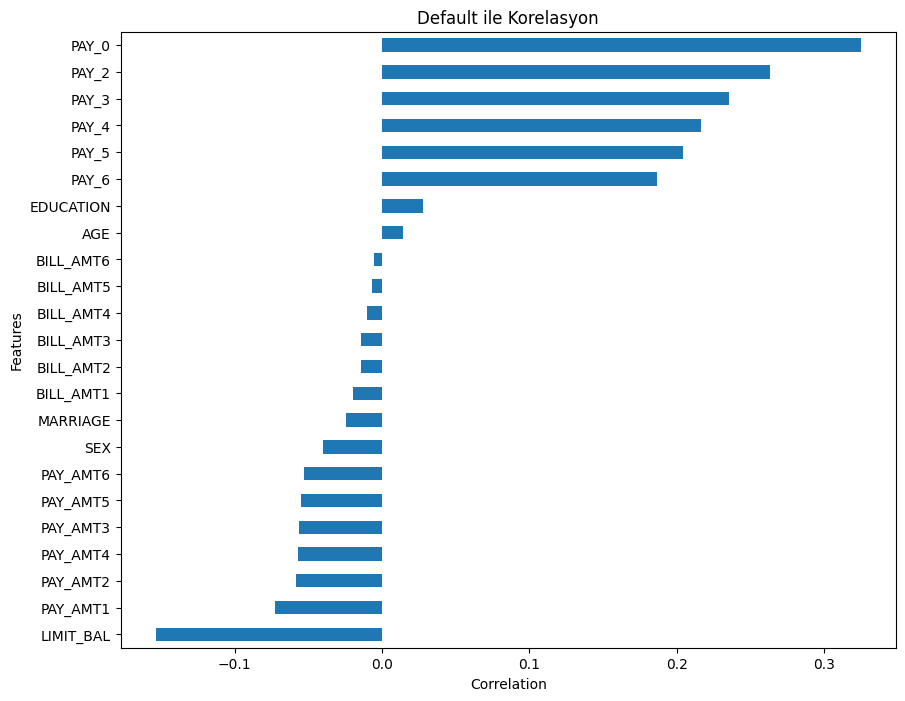

In [ ]:
# 18) Default ile en ilişkili özellikler
target_corr = df.corr(numeric_only=True)["default"].drop("default").sort_values()

plt.figure(figsize=(10, 8))
target_corr.plot(kind="barh")
plt.title("Default ile Korelasyon")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

In [ ]:
# 19) Train-test ayırma ve scaling
X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (24000, 23)
X_test: (6000, 23)


In [ ]:
# 20) Modelleri eğitme
models = {}

models["K-NN"] = KNeighborsClassifier(n_neighbors=5)
models["K-NN"].fit(X_train_scaled, y_train)

In [ ]:

models["Linear Regression"] = LinearRegression()
models["Linear Regression"].fit(X_train, y_train)

In [ ]:
models["Logistic Regression"] = LogisticRegression(max_iter=1000)
models["Logistic Regression"].fit(X_train_scaled, y_train)

In [ ]:
models["Naive Bayes"] = GaussianNB()
models["Naive Bayes"].fit(X_train, y_train)

In [ ]:
models["Decision Tree"] = DecisionTreeClassifier(max_depth=4, random_state=42)
models["Decision Tree"].fit(X_train, y_train)

In [ ]:
models["Random Forest"] = RandomForestClassifier(n_estimators=150, random_state=42)
models["Random Forest"].fit(X_train, y_train)

In [ ]:
models["SVM"] = SVC(kernel="linear", probability=True, random_state=42)
models["SVM"].fit(X_train_scaled, y_train)

In [ ]:
models["YSA"] = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42
)
models["YSA"].fit(X_train_scaled, y_train)

In [ ]:
# 30) CNN için veri hazırlama
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout

X_train_cnn = np.array(X_train_scaled).reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = np.array(X_test_scaled).reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

# 31) CNN modeli
model_cnn = Sequential()
model_cnn.add(Conv1D(64, 2, activation="relu", input_shape=(X_train_cnn.shape[1], 1)))
model_cnn.add(Conv1D(32, 2, activation="relu"))
model_cnn.add(Flatten())
model_cnn.add(Dense(32, activation="relu"))
model_cnn.add(Dropout(0.3))
model_cnn.add(Dense(1, activation="sigmoid"))

model_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_cnn = model_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

In [ ]:
# 21) Tahminler
predictions = {}

for name, model in models.items():
    if name in ["K-NN", "Logistic Regression", "SVM", "YSA"]:
        pred = model.predict(X_test_scaled)
    elif name == "Linear Regression":
        pred_continuous = model.predict(X_test)
        pred = (pred_continuous >= 0.5).astype(int)
    else:
        pred = model.predict(X_test)

    predictions[name] = pred
    print("\n==============================")
    print(name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))


K-NN
Accuracy: 0.7928333333333333
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.55      0.36      0.43      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.64      0.65      6000
weighted avg       0.77      0.79      0.78      6000


Linear Regression
Accuracy: 0.801
              precision    recall  f1-score   support

           0       0.81      0.98      0.88      4673
           1       0.72      0.16      0.26      1327

    accuracy                           0.80      6000
   macro avg       0.76      0.57      0.57      6000
weighted avg       0.79      0.80      0.75      6000


Logistic Regression
Accuracy: 0.8076666666666666
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro

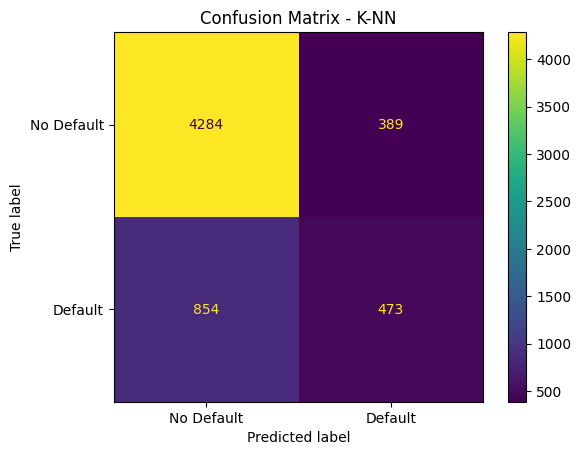

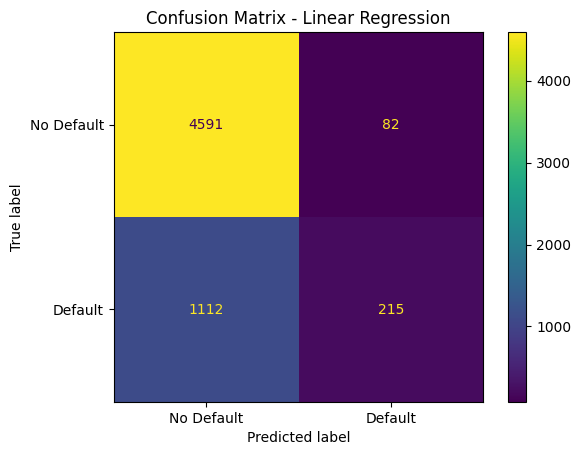

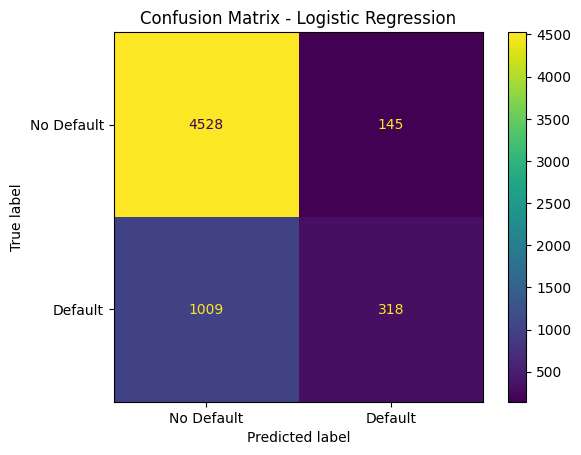

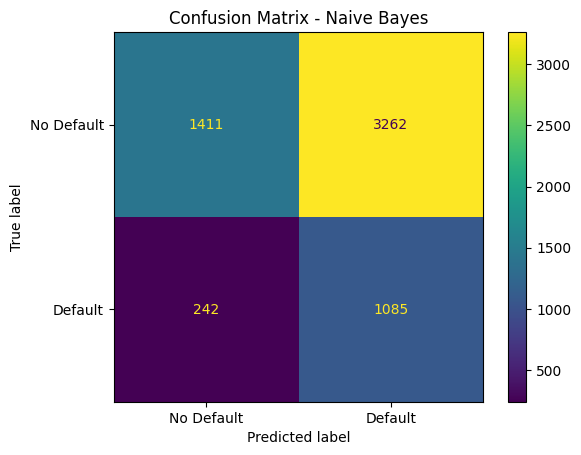

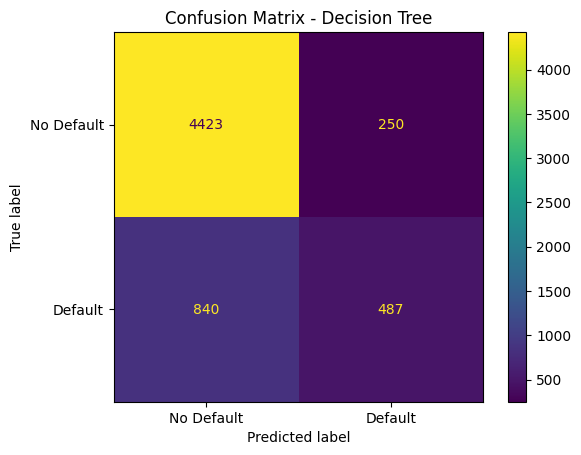

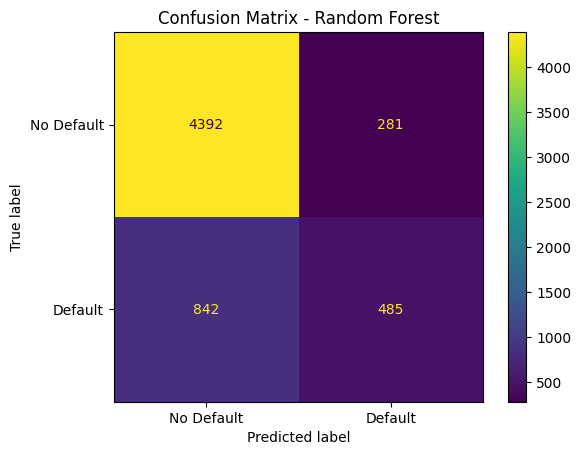

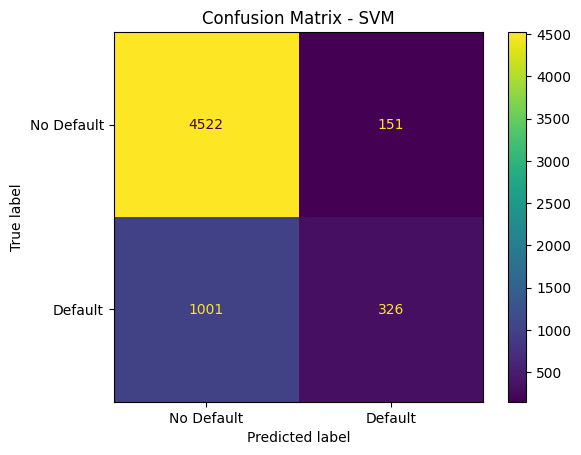

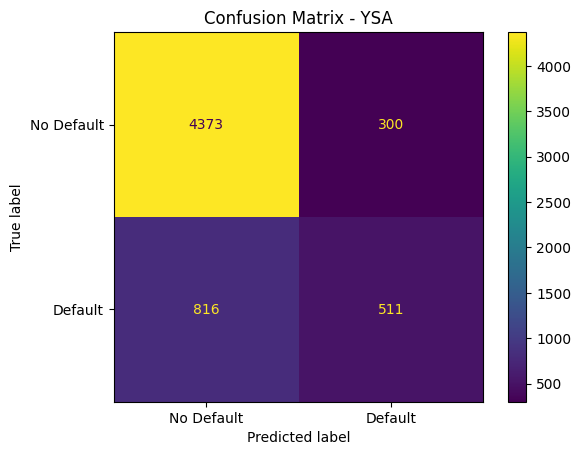

In [ ]:
# 22) Confusion Matrix grafikleri
for name, pred in predictions.items():
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

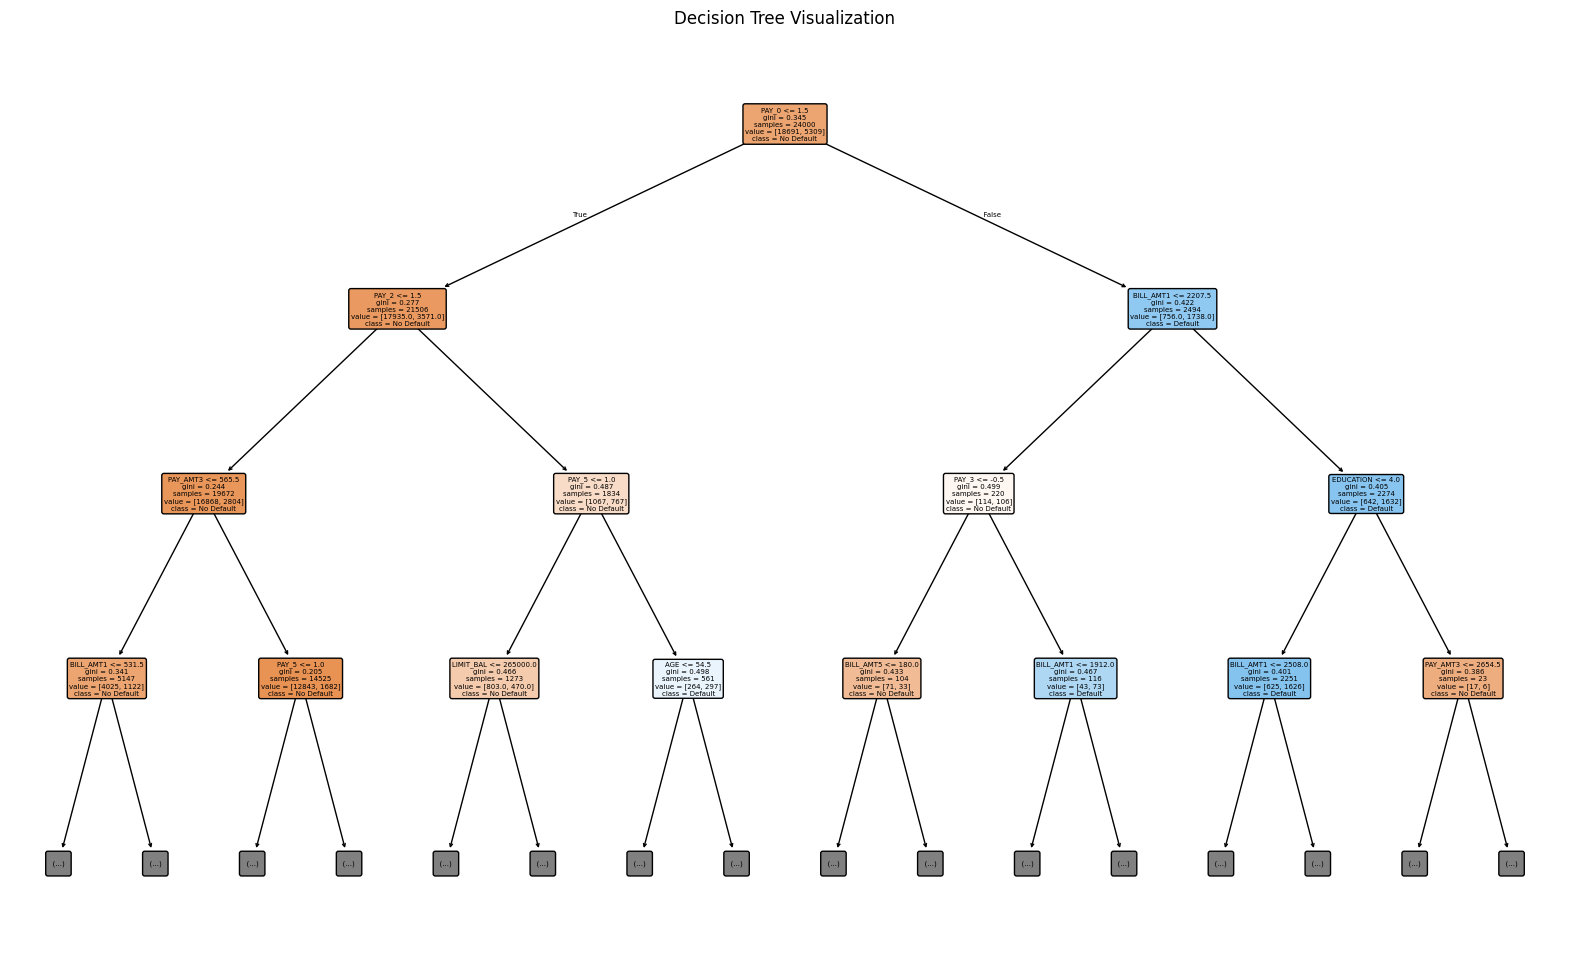

In [ ]:
# 24) Decision Tree görselleştirme - senin mevcut grafiğin
plt.figure(figsize=(20, 12))
plot_tree(
    models["Decision Tree"],
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Decision Tree Visualization")
plt.show()

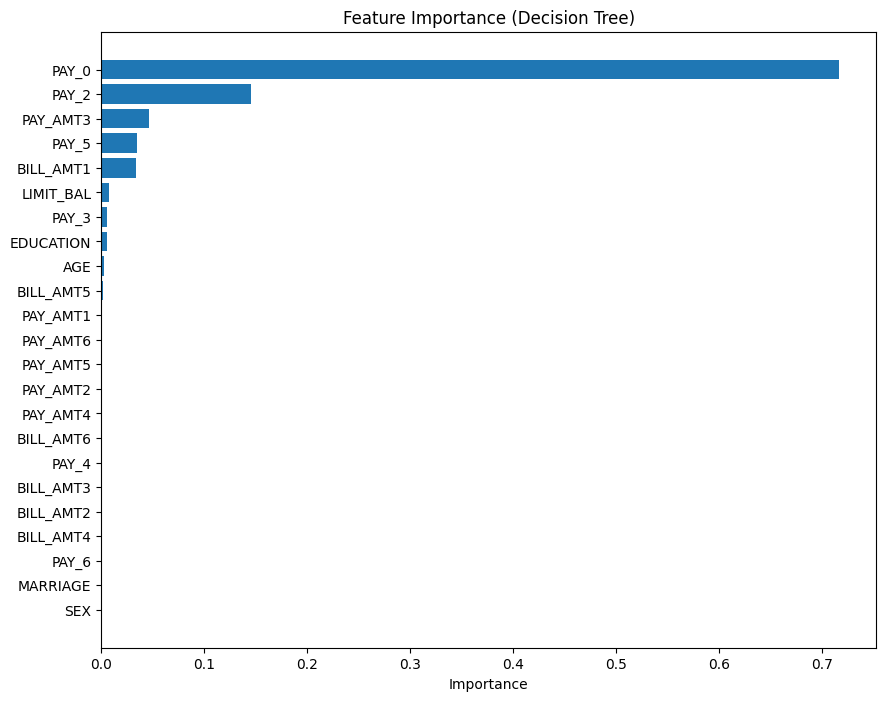

In [ ]:
# 25) Feature Importance - Decision Tree
importance_dt = models["Decision Tree"].feature_importances_
features = X.columns

dt_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance_dt
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(dt_importance["Feature"], dt_importance["Importance"])
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.show()

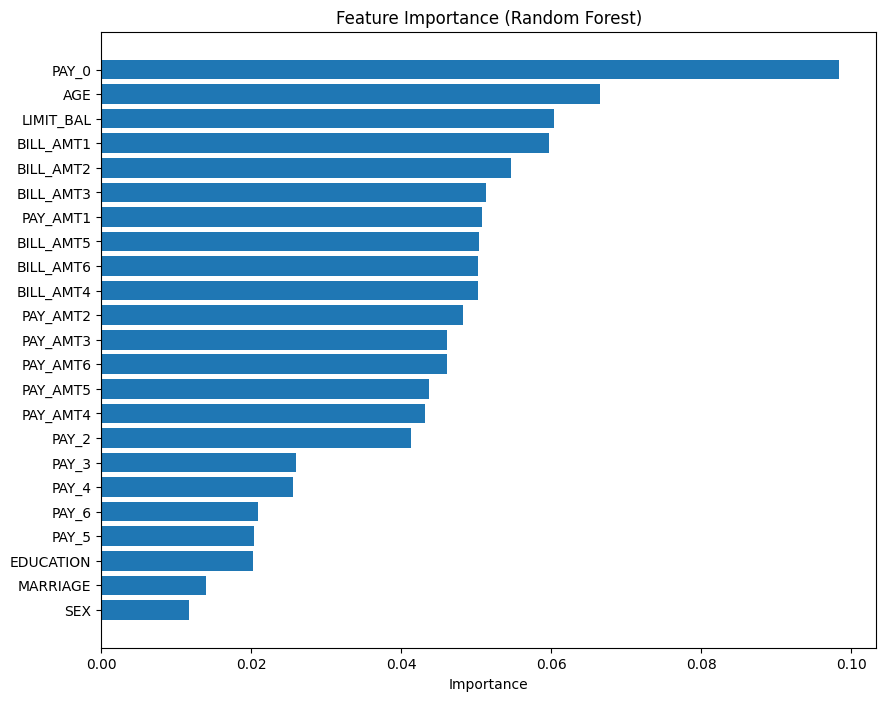

In [ ]:
# 26) Feature Importance - Random Forest
importance_rf = models["Random Forest"].feature_importances_

rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance_rf
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [ ]:
# 27) Metrik tablosu
results = []

for name, pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0)
    })

sonuclar = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
sonuclar

,Model,Accuracy,Precision,Recall,F1-Score
4,Decision Tree,0.818333,0.660787,0.366993,0.471899
7,YSA,0.814000,0.630086,0.385079,0.478017
5,Random Forest,0.812833,0.633159,0.365486,0.463450
6,SVM,0.808000,0.683438,0.245667,0.361419
2,Logistic Regression,0.807667,0.686825,0.239638,0.355307
1,Linear Regression,0.801000,0.723906,0.162020,0.264778
0,K-NN,0.792833,0.548724,0.356443,0.432161
3,Naive Bayes,0.416000,0.249597,0.817634,0.382446


In [ ]:
# 32) CNN sonuçları
loss, accuracy_cnn = model_cnn.evaluate(X_test_cnn, y_test)
print("CNN Accuracy:", accuracy_cnn)

y_pred_cnn_prob = model_cnn.predict(X_test_cnn).ravel()
y_pred_cnn = (y_pred_cnn_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred_cnn))

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8153 - loss: 0.4430
CNN Accuracy: 0.8153333067893982
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.65      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



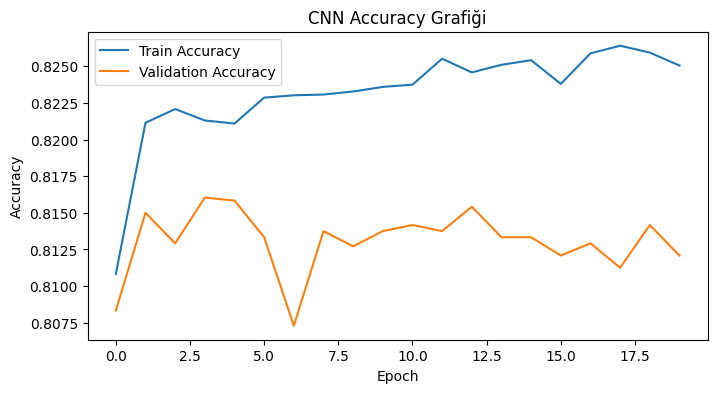

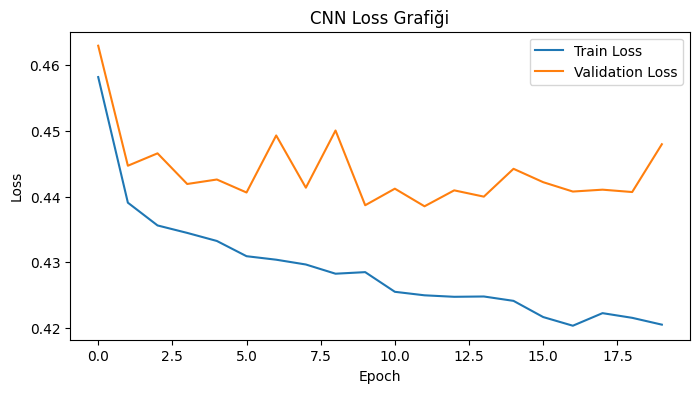

In [ ]:
# 33) CNN eğitim grafikleri
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# 34) CNN'i de sonuç tablosuna ekleme
cnn_row = pd.DataFrame([{
    "Model": "CNN",
    "Accuracy": accuracy_score(y_test, y_pred_cnn),
    "Precision": precision_score(y_test, y_pred_cnn, zero_division=0),
    "Recall": recall_score(y_test, y_pred_cnn, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_cnn, zero_division=0)
}])

final_sonuclar = pd.concat([sonuclar, cnn_row], ignore_index=True).sort_values(by="Accuracy", ascending=False)
final_sonuclar

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.818333,0.660787,0.366993,0.471899
8,CNN,0.815333,0.645033,0.366993,0.467819
1,YSA,0.814000,0.630086,0.385079,0.478017
2,Random Forest,0.812833,0.633159,0.365486,0.463450
3,SVM,0.808000,0.683438,0.245667,0.361419
4,Logistic Regression,0.807667,0.686825,0.239638,0.355307
5,Linear Regression,0.801000,0.723906,0.162020,0.264778
6,K-NN,0.792833,0.548724,0.356443,0.432161
7,Naive Bayes,0.416000,0.249597,0.817634,0.382446


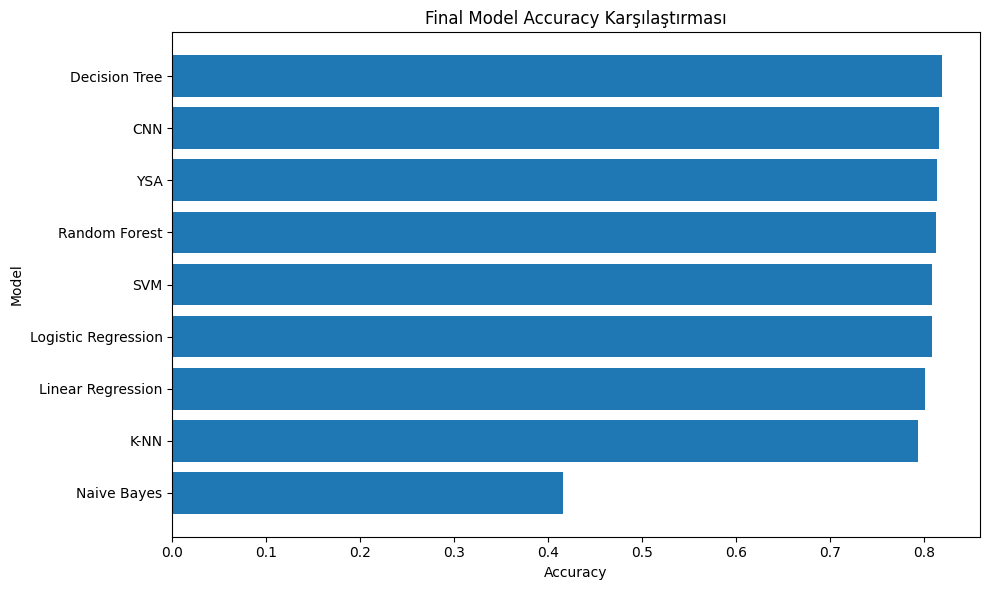

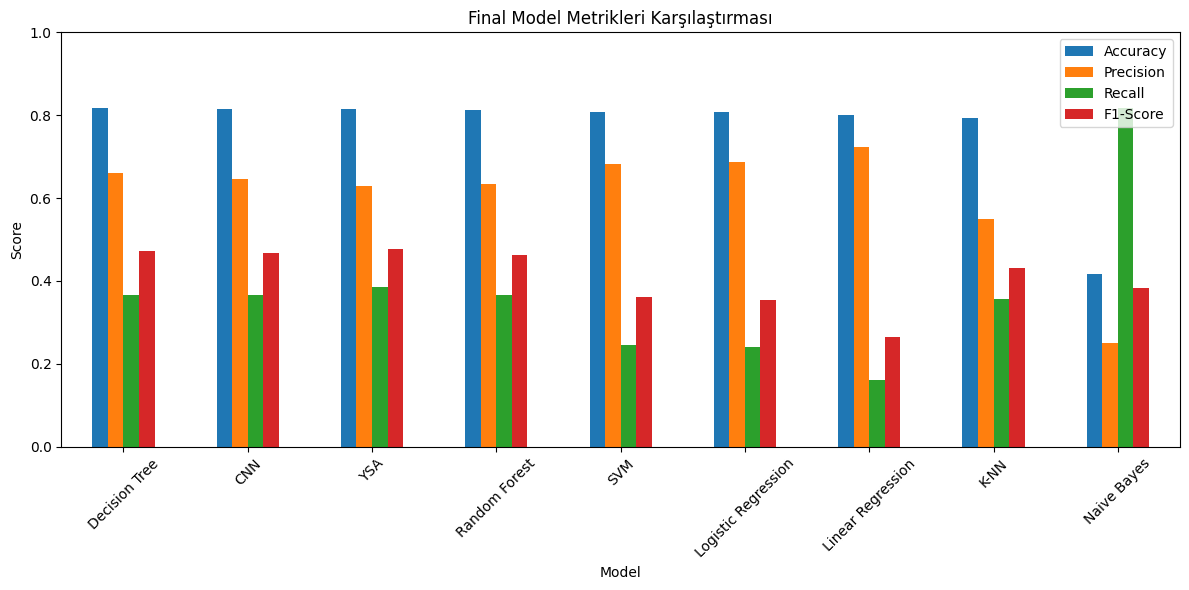

In [ ]:
# 35) Final model karşılaştırma grafiği
final_sorted = final_sonuclar.sort_values(by="Accuracy")

plt.figure(figsize=(10, 6))
plt.barh(final_sorted["Model"], final_sorted["Accuracy"])
plt.title("Final Model Accuracy Karşılaştırması")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

final_sonuclar.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Final Model Metrikleri Karşılaştırması")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

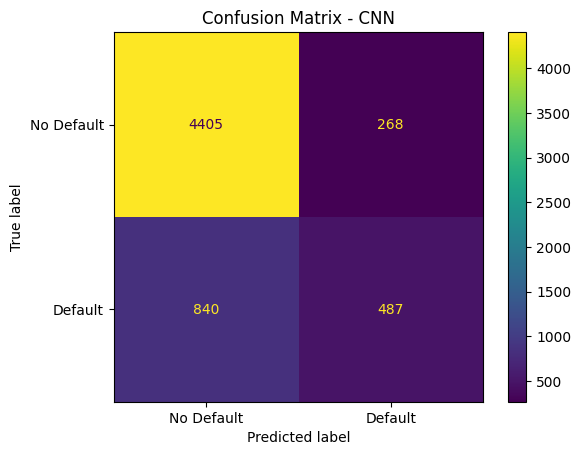

In [ ]:
# 36) Final Confusion Matrix - CNN
cm = confusion_matrix(y_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
disp.plot()
plt.title("Confusion Matrix - CNN")
plt.show()

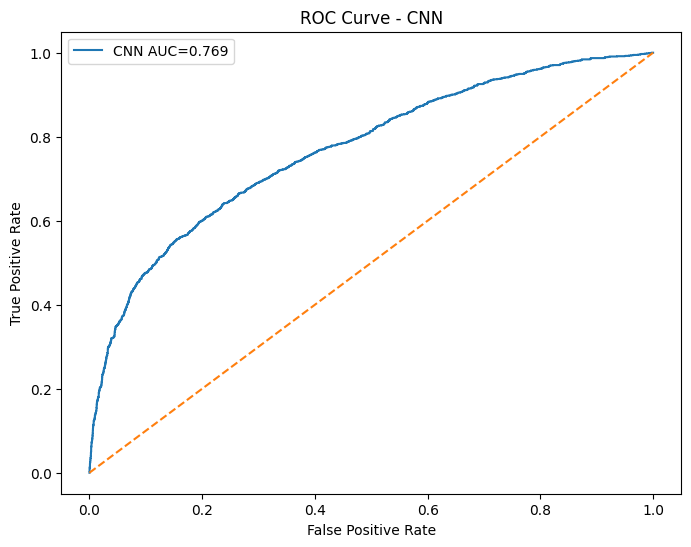

In [ ]:
# 37) Tek Başına CNN Curve Grafiği
fpr, tpr, _ = roc_curve(y_test, y_pred_cnn_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"CNN AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN")
plt.legend()
plt.show()

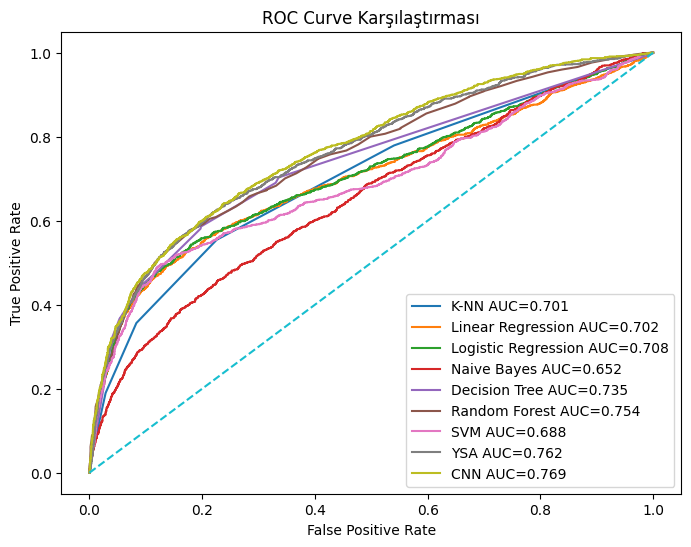

In [ ]:
# 23) ROC Curve grafikleri
plt.figure(figsize=(8, 6))

for name, model in models.items():
    try:
        if name in ["K-NN", "Logistic Regression", "SVM", "YSA"]:
            if hasattr(model, "predict_proba"):
                score = model.predict_proba(X_test_scaled)[:, 1]
            else:
                score = model.decision_function(X_test_scaled)
        elif name == "Linear Regression":
            score = model.predict(X_test)
        else:
            if hasattr(model, "predict_proba"):
                score = model.predict_proba(X_test)[:, 1]
            else:
                continue

        fpr, tpr, _ = roc_curve(y_test, score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")
    except Exception as e:
        print(name, "ROC çizilemedi:", e)


# CNN ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_cnn_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"CNN AUC={roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Karşılaştırması")
plt.legend()
plt.show()